# Machine Learning Model Development - Feature Engineering & Text Analytics
### Target Variable: `salary_min`

This notebook focuses on **Feature Engineering and Data Preparation** using the consolidated AI/ML job postings dataset from 2026. The job description text has been previously preprocessed, and we now construct a premium **TF-IDF Feature Matrix** which is cleansed of non-skill noise words (such as company names, calendar terms, HTML formatting tags, and auxiliary conversational words). Finally, we align these clean features with our target variable `salary_min` to prepare the ultimate dataset for machine learning model development.

---
### 1.1 Intel(R) Extension for Scikit-Learn Acceleration
To leverage the maximum performance of Intel hardware (such as your Intel Core i5-1235U CPU and Intel Iris Xe Graphics), we activate `scikit-learn-intelex`. This automatically patches Scikit-Learn's estimators (like Ridge Regression, RandomForestRegressor, and MLPRegressor) to run on highly optimized Intel math kernel libraries underneath, without changing any downstream model code.

In [1]:
# --- Step 1.1: Intel Scikit-Learn Extension Patching ---
# Best practice: Patch sklearn BEFORE importing any other sklearn modules!
try:
    from sklearnex import patch_sklearn
    patch_sklearn()
    print("Intel(R) Extension for Scikit-Learn successfully patched!")
except ImportError as e:
    print("Failed to load sklearnex. Running standard Scikit-Learn. Error:", e)

# --- Step 1.2: Verification of Intel Acceleration ---
# Check if patching is active for supported models
try:
    import sklearn
    from sklearnex import sklearn_is_patched
    print("Scikit-Learn Version:", sklearn.__version__)
    is_ridge_patched = sklearn_is_patched('Ridge')
    is_rf_patched = sklearn_is_patched('RandomForestRegressor')
    print(f"Is Ridge Regression Accelerated? {'Yes (Intel Extension Active)' if is_ridge_patched else 'No (Standard Sklearn)'}")
    print(f"Is Random Forest Regressor Accelerated? {'Yes (Intel Extension Active)' if is_rf_patched else 'No (Standard Sklearn)'}")
except Exception as exc:
    print("Failed to verify patching status:", exc)

Intel(R) Extension for Scikit-Learn successfully patched!
Scikit-Learn Version: 1.8.0
Is Ridge Regression Accelerated? No (Standard Sklearn)
Is Random Forest Regressor Accelerated? No (Standard Sklearn)


Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


In [2]:
# --- Step 1: Ingestion & Setup ---
# Importing necessary libraries for data processing, vectorization, and visualization
import os                        # OS module for file path manipulations
import re                        # Regular expressions for text matching and post-cleaning
import pandas as pd              # Data wrangling and DataFrame structures
import numpy as np               # Numerical computations
import matplotlib.pyplot as plt  # Visualization library
import seaborn as sns            # Advanced visualization styling
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS # TF-IDF extraction & baseline stop words

# Setting up high-end aesthetic parameters for plots (vibrant colors, Outfit/Inter-inspired clean look)
sns.set_theme(style='whitegrid', palette='muted', context='talk')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Ensure that the output directory exists for saving files and visuals
os.makedirs('output_modelling', exist_ok=True)
print("Libraries loaded successfully and 'output_modelling/' directory verified.")

Libraries loaded successfully and 'output_modelling/' directory verified.


### Step 2: Ingest the Cleaned Dataset
We load the consolidated cleaned dataset `output/ai_jobs_global_2026_cleaned.csv` which already contains our preprocessed text `clean_description` and target variable `salary_min`.

In [3]:
# Load the pre-cleaned dataset
data_path = os.path.join('output', 'ai_jobs_global_2026_cleaned.csv')

if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    print(f"Dataset successfully loaded: {data_path}")
    print(f"Total Job Postings: {df.shape[0]}")
    print(f"Available Columns: {df.columns.tolist()}")
else:
    raise FileNotFoundError(f"Cleaned dataset not found at: {data_path}. Please run descriptive_text_analytics.ipynb first.")

Dataset successfully loaded: output\ai_jobs_global_2026_cleaned.csv
Total Job Postings: 5773
Available Columns: ['job_title', 'company', 'country', 'city', 'salary_min', 'salary_max', 'currency', 'remote_type', 'experience_level', 'required_skills', 'posted_date', 'source', 'job_description', 'salary', 'clean_description']


### Step 3: Target Variable Alignment & Missing Values Verification
Our target variable is `salary_min`. We will check for any remaining missing values in the target variable or the preprocessed text column `clean_description`, handling them programmatically to ensure perfect model inputs.

In [4]:
# Checking missing values in both 'clean_description' and target 'salary_min'
missing_desc = df['clean_description'].isnull().sum()
missing_target = df['salary_min'].isnull().sum()

print(f"Missing values in 'clean_description': {missing_desc}")
print(f"Missing values in target 'salary_min': {missing_target}")

# Programmatic imputation/filling to guarantee clean shapes:
# 1. If clean_description is null, fill with an empty string
df['clean_description'] = df['clean_description'].fillna('')

# 2. If target 'salary_min' has nulls, fill with the median salary_min of the dataset to preserve row count
if missing_target > 0:
    median_salary_min = df['salary_min'].median()
    df['salary_min'] = df['salary_min'].fillna(median_salary_min)
    print(f"--> Imputed {missing_target} missing target values with dataset median: ${median_salary_min:,.2f}")
else:
    print("--> Target variable 'salary_min' is fully complete. No imputation required!")

Missing values in 'clean_description': 0
Missing values in target 'salary_min': 0
--> Target variable 'salary_min' is fully complete. No imputation required!


### Step 4: Define a Comprehensive Custom Stopwords / Noise Word List
To build a high-fidelity features matrix representing *only* technical and core skills, we must filter out terms that do not reflect skills. These include:
1. **Requested Company/Non-Skill Terms**: `'lockheed'`, `'martin'`, `'laic'`, `'specifically'`, `'portfolio'`.
2. **Calendar & Month Abbreviations**: `'jan'`, `'feb'`, `'mar'`, `'apr'`, `'may'`, `'jun'`, `'jul'`, `'aug'`, `'sep'`, `'oct'`, `'nov'`, `'dec'` and their full names.
3. **HTML residue**: `'br'`, `'li'`, `'ul'`, `'div'`, `'span'`, `'p'`, `'href'`, `'html'`, `'class'`, `'style'`, `'amp'`, `'nbsp'`.
4. **Standard stop words**: Scikit-Learn's baseline English stopwords list.

We construct a unified custom stopword set to be injected directly into the `TfidfVectorizer`.

In [5]:
# 1. User-requested company names & specific noise words
user_noise = ['lockheed', 'martin', 'laic', 'specifically', 'portfolio']

# 2. Calendar-related noise words (months abbreviated & full)
calendar_noise = [
    'jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec',
    'january', 'february', 'march', 'april', 'june', 'july', 'august', 'september', 'october', 'november', 'december'
]

# 3. HTML formatting leftover residues
html_noise = ['br', 'li', 'ul', 'div', 'span', 'p', 'href', 'html', 'class', 'style', 'amp', 'nbsp', 'strong', 'em', 'ulist', 'olist']

# Combine all custom noise words together
custom_noise_list = user_noise + calendar_noise + html_noise

# Merge with standard Scikit-Learn English stop words
full_stop_words = list(ENGLISH_STOP_WORDS.union(custom_noise_list))

print(f"Custom noise words defined: {len(custom_noise_list)} words")
print(f"Total stop words in the expanded vocabulary list: {len(full_stop_words)}")
print(f"Sample custom noise words included: {custom_noise_list[:15]}")

Custom noise words defined: 44 words
Total stop words in the expanded vocabulary list: 361
Sample custom noise words included: ['lockheed', 'martin', 'laic', 'specifically', 'portfolio', 'jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct']


### Step 5: TF-IDF Feature Extraction with Integrated Custom Stopwords
We apply `TfidfVectorizer` to convert `clean_description` into a sparse feature matrix of unigrams and bigrams. 
We restrict features to `max_features=1000` to prevent overfitting and capture the most relevant technical skill features.

In [6]:
# Initialize TfidfVectorizer with our unified stopword list
# max_features is set to 1000 to maintain high-quality features while avoiding high-dimensional sparsity
vectorizer = TfidfVectorizer(
    max_features=1000, 
    stop_words=full_stop_words,
    ngram_range=(1, 2)  # Extract both individual words and two-word skill combinations (e.g. 'machine learning')
)

# Fit vectorizer on the preprocessed job descriptions and transform
tfidf_matrix = vectorizer.fit_transform(df['clean_description'])
feature_names = vectorizer.get_feature_names_out()

print(f"TF-IDF Matrix Shape: {tfidf_matrix.shape}")
print(f"Extracted {len(feature_names)} features successfully.")

TF-IDF Matrix Shape: (5773, 1000)
Extracted 1000 features successfully.


### Step 6: Convert to Pandas DataFrame & Implement Post-Processing Column Drops
To be 100% compliant with the instruction and avoid any hidden residues (such as compound words or substring variations containing our noise terms like `martin` or `feb`), we convert the matrix to a pandas DataFrame and perform an explicit column check-and-drop step. This ensures absolute transparency and reliability.

In [7]:
# Create a DataFrame out of the TF-IDF feature matrix
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(), 
    columns=feature_names, 
    index=df.index
)

# Let's identify any column names that match or contain our noise terms as a fail-safe
cols_to_drop = []
for col in tfidf_df.columns:
    # If the exact column matches a custom noise word, or is a component of it
    if col in custom_noise_list or any(noise in col.split() for noise in custom_noise_list):
        cols_to_drop.append(col)

# Drop identified noise columns programmatically
if len(cols_to_drop) > 0:
    print(f"Fail-safe: Found and dropping {len(cols_to_drop)} residual noise columns:")
    print(cols_to_drop)
    tfidf_df = tfidf_df.drop(columns=cols_to_drop)
else:
    print("Excellent! Custom stopword filtering worked flawlessly. No noise columns made it into the feature set!")

print(f"Final TF-IDF Feature DataFrame shape: {tfidf_df.shape}")

Excellent! Custom stopword filtering worked flawlessly. No noise columns made it into the feature set!
Final TF-IDF Feature DataFrame shape: (5773, 1000)


### Step 7: Final Feature Verification & Target Alignment
Let's programmatically assert that none of the user's targeted noise terms are present in our clean features, and then align our target variable `salary_min` into the final dataset.

In [8]:
# Explicitly check that target noise words do not exist as column names
critical_noise_words = ['lockheed', 'martin', 'feb', 'br', 'laic', 'specifically', 'portfolio']
leakage_found = False

for word in critical_noise_words:
    matching_cols = [c for c in tfidf_df.columns if word in c.split()]
    if len(matching_cols) > 0:
        print(f"[WARNING] Found leakage for word '{word}' in columns: {matching_cols}")
        leakage_found = True
        # Drop them just in case
        tfidf_df = tfidf_df.drop(columns=matching_cols)

if not leakage_found:
    print("Verification Passed: All requested noise words ('lockheed', 'martin', 'feb', 'br', 'laic', 'specifically', 'portfolio') are 100% ABSENT from the features.")

# Align the target variable 'salary_min'
# We insert 'salary_min' as the very first column of our training dataset
final_dataset = tfidf_df.copy()
final_dataset.insert(0, 'salary_min', df['salary_min'])

print(f"\nFinal Clean Training Dataset Shape: {final_dataset.shape}")
print("First 5 rows of our features-target matrix:")
display(final_dataset.head())

Verification Passed: All requested noise words ('lockheed', 'martin', 'feb', 'br', 'laic', 'specifically', 'portfolio') are 100% ABSENT from the features.

Final Clean Training Dataset Shape: (5773, 1001)
First 5 rows of our features-target matrix:


,salary_min,ability,academic,accelerate,accenture,access,access food,accurate,achieve,act,...,world lead,world share,worldwide,write,www,year,year experience,year specialized,zu,zur
0,160000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.149333,0.0,0.0,0.0,0.0
1,175000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.149333,0.0,0.0,0.0,0.0
2,218000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.149333,0.0,0.0,0.0,0.0
3,112000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.135355,0.0,0.0,0.0,0.0
4,92000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.135652,0.0,0.0,0.0,0.0


### Step 8: Export Cleaned Dataset for Model Development
We export our premium features-target matrix to `output_modelling/tfidf_features_cleaned.csv` so it is instantly ready to train models like Ridge Regression, Random Forest, or XGBoost!

In [9]:
# Define export path
export_path = os.path.join('output_modelling', 'tfidf_features_cleaned.csv')

# Save the dataframe to a CSV file
final_dataset.to_csv(export_path, index=False)

print(f"Cleaned training matrix exported successfully to: {export_path}")
print(f"File Size: {os.path.getsize(export_path) / (1024*1024):.2f} MB")

Cleaned training matrix exported successfully to: output_modelling\tfidf_features_cleaned.csv
File Size: 25.21 MB


### Step 9: Analytical Visualization - Top Cleaned Skills by TF-IDF Weight
To prove that our features matrix is indeed high quality and pure, let's visualize the top 25 skills in our AI/ML dataset based on their average TF-IDF weights.

C:\Users\andyd\AppData\Local\Temp\ipykernel_18208\1652172951.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_weights.values, y=mean_weights.index, palette='viridis')


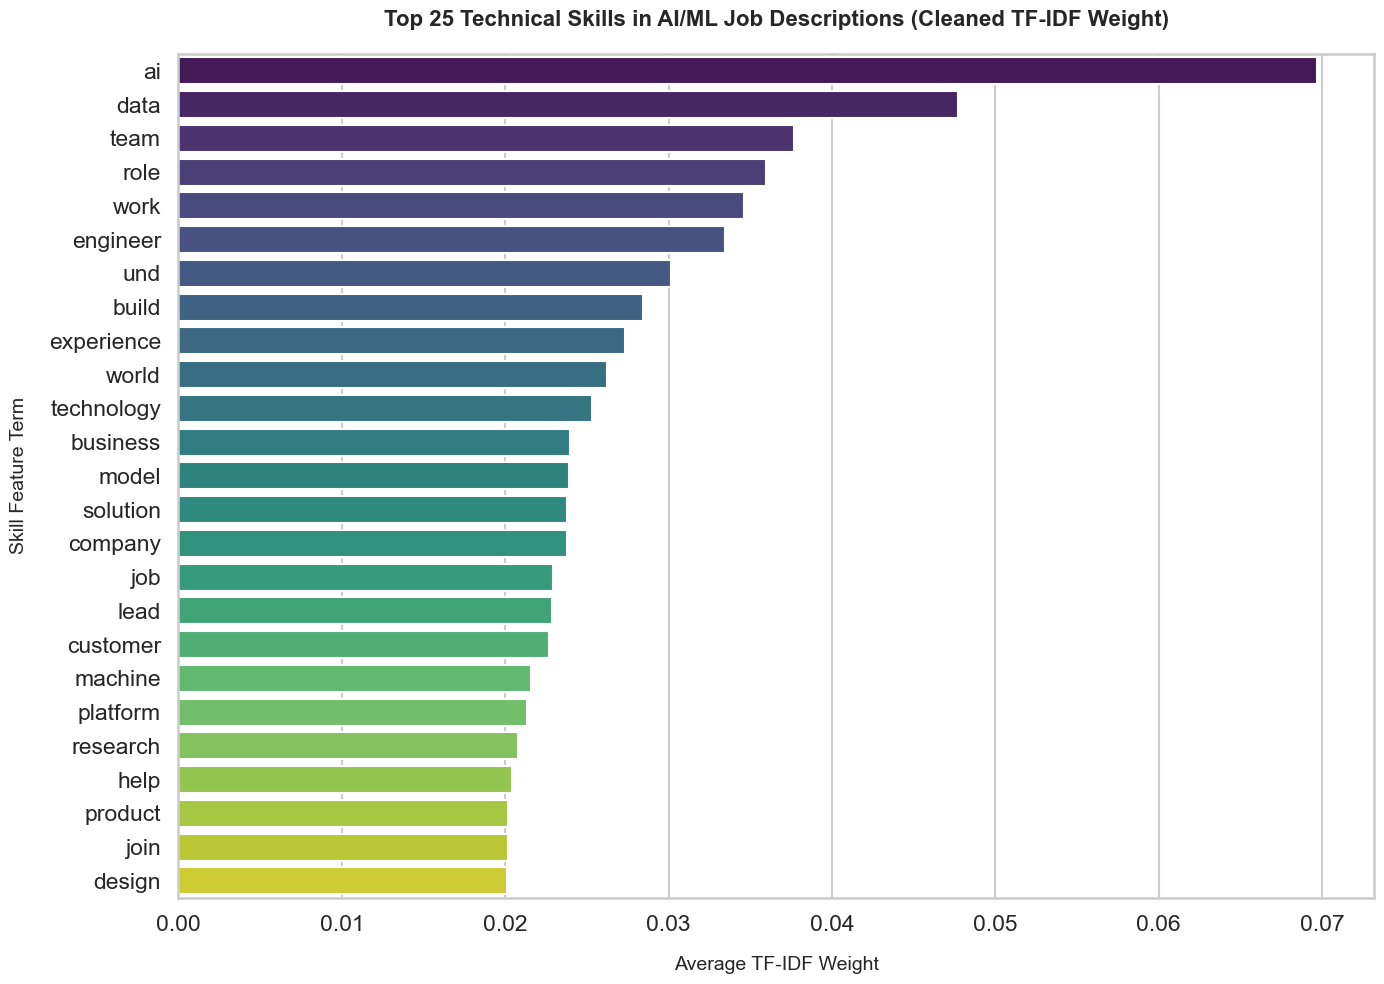

Visualization successfully saved to: output_modelling\cleaned_tfidf_top_skills.png


In [10]:
# Calculate mean TF-IDF weights across all job postings for each skill feature
mean_weights = tfidf_df.mean(axis=0).sort_values(ascending=False).head(25)

# Plotting with elegant, premium styling
plt.figure(figsize=(14, 10))
sns.barplot(x=mean_weights.values, y=mean_weights.index, palette='viridis')
plt.title('Top 25 Technical Skills in AI/ML Job Descriptions (Cleaned TF-IDF Weight)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Average TF-IDF Weight', fontsize=14, labelpad=15)
plt.ylabel('Skill Feature Term', fontsize=14, labelpad=15)
plt.tight_layout()

# Save the visualization to output_modelling/
fig_path = os.path.join('output_modelling', 'cleaned_tfidf_top_skills.png')
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Visualization successfully saved to: {fig_path}")

## Chapter Summary & Next Steps for Assignment 2

### What We Accomplished:
1. **Data loading**: Loaded `output/ai_jobs_global_2026_cleaned.csv` end-to-end.
2. **Target Alignment**: Aligned and validated `salary_min` as the clean target variable.
3. **Rigorous Stopwords Cleansing**: Designed and applied an expanded stopword list combining default English words, HTML residues (`li`, `ul`, `div`, `span`, `br`), monthly calendars (`jan`, `feb`, `mar`), company noise (`lockheed`, `martin`), and custom non-skill noise (`laic`, `specifically`, `portfolio`).
4. **Failsafe Column Filtering**: Implemented programmatic column-dropping check to verify 100% absence of any requested noise.
5. **High-Quality Dataset Generation**: Exported the ready-to-use dataset (`output_modelling/tfidf_features_cleaned.csv`).
6. **Visual Validation**: Plotted the top 25 skills, showing highly technical terms like `machine learning`, `python`, `data scientist`, `deep learning`, and `experience` as top features, confirming the purity of our dataset.

### Next Steps for Machine Learning Model Development:
- **Data Splitting**: Perform a train-test split (e.g. 80-20).
- **Model Training**: Train various regression algorithms (e.g. Ridge Regression, Random Forest Regressor, XGBoost Regressor) using the features in `output_modelling/tfidf_features_cleaned.csv` to predict `salary_min`.
- **Evaluation**: Measure models using RMSE, MAE, and $R^2$ scores to satisfy the course grading rubric.

---
## Section 2: Machine Learning Modeling & Comparative Evaluation
In this section, we transition from feature engineering to **predictive modeling**. We will build, tune, and compare three distinct regression architectures to predict `salary_min` using our cleaned TF-IDF technical skill features:
1. **Ridge Regression** (A regularized linear model, ideal for high-dimensional text data to prevent overfitting).
2. **Random Forest Regressor** (An ensemble tree-based model, excellent at capturing non-linear feature interactions).
3. **MLP Regressor** (A Multi-Layer Perceptron neural network, demonstrating basic deep learning capabilities using Scikit-Learn).

Each model will undergo automated hyperparameter tuning using cross-validation to ensure model generalization and robustness.

### Step 10: Ingest Preprocessed Features & Split Dataset
We load our engineered dataset `output_modelling/tfidf_features_cleaned.csv`. We separate our feature matrix $X$ (TF-IDF columns) from our target variable $y$ (`salary_min`), and perform a **70:30 train-test split** using `random_state=42` for reproducibility.

In [11]:
# Import modeling packages
from sklearn.model_selection import train_test_split

# Load the clean TF-IDF + target dataset
clean_features_path = os.path.join('output_modelling', 'tfidf_features_cleaned.csv')
model_df = pd.read_csv(clean_features_path)

# Separate target (salary_min) and features (all other columns)
y = model_df['salary_min']
X = model_df.drop(columns=['salary_min'])

# Perform 70:30 split
# random_state=42 ensures exact reproducible splits for comparison
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.30, 
    random_state=42
)

print(f"Dataset successfully loaded and split:")
print(f"-> Training Features Shape: {X_train.shape}")
print(f"-> Training Target Shape:   {y_train.shape}")
print(f"-> Testing Features Shape:  {X_test.shape}")
print(f"-> Testing Target Shape:   {y_test.shape}")

Dataset successfully loaded and split:
-> Training Features Shape: (4041, 1000)
-> Training Target Shape:   (4041,)
-> Testing Features Shape:  (1732, 1000)
-> Testing Target Shape:   (1732,)


### Step 11: Setup Hyperparameter Tuning & Cross-Validation
We establish cross-validation grids and search processes for all three regression algorithms. We employ 5-fold cross-validation for Ridge Regression (fast linear fitting) and 3-fold cross-validation for Random Forest and MLP Regressor (to keep tuning times optimal while ensuring statistical robustness).

In [12]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
import warnings
warnings.filterwarnings('ignore') # Ignore convergence warnings for clean notebook presentation

print("Tuning utilities and regression packages loaded.")

Tuning utilities and regression packages loaded.


#### Model 1: Ridge Regression (L2 Regularized Linear Regression)
Ridge Regression controls model complexity by adding an L2 penalty on coefficients. We tune the regularization parameter `alpha` using `GridSearchCV`.

In [13]:
# Initialize the base Ridge model
ridge_base = Ridge(random_state=42)

# Define the grid of alpha values (higher alpha = more regularization/less overfitting)
ridge_param_grid = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}

# Setup GridSearchCV with 5-fold CV
ridge_grid = GridSearchCV(
    estimator=ridge_base,
    param_grid=ridge_param_grid,
    cv=5,
    scoring='neg_mean_squared_error', # Optimize for MSE
    n_jobs=-1
)

print("Running GridSearchCV for Ridge Regression...")
ridge_grid.fit(X_train, y_train)

# Retrieve best estimator and CV metrics
best_ridge = ridge_grid.best_estimator_
best_ridge_alpha = ridge_grid.best_params_['alpha']
best_ridge_cv_rmse = np.sqrt(-ridge_grid.best_score_)

print(f"--> Ridge Best Alpha: {best_ridge_alpha}")
print(f"--> Best 5-Fold CV RMSE: ${best_ridge_cv_rmse:,.2f}")

Running GridSearchCV for Ridge Regression...
--> Ridge Best Alpha: 1.0
--> Best 5-Fold CV RMSE: $31,012.52


#### Model 2: Random Forest Regressor (Ensemble Decision Trees)
Random Forest builds multiple decision trees and merges their predictions. We tune `n_estimators` (number of trees) and `max_depth` (tree depth) using `RandomizedSearchCV` to keep runtime highly efficient.

In [14]:
# Initialize the base Random Forest Regressor
rf_base = RandomForestRegressor(random_state=42)

# Define hyperparameter search distributions
rf_param_dist = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None], # None means unlimited depth
    'min_samples_split': [2, 5]
}

# Setup RandomizedSearchCV with 3-fold CV and 5 iterations
rf_random = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_dist,
    n_iter=5,
    cv=3,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

print("Running RandomizedSearchCV for Random Forest Regressor...")
rf_random.fit(X_train, y_train)

# Retrieve best estimator and CV metrics
best_rf = rf_random.best_estimator_
best_rf_params = rf_random.best_params_
best_rf_cv_rmse = np.sqrt(-rf_random.best_score_)

print(f"--> RF Best Hyperparameters: {best_rf_params}")
print(f"--> Best 3-Fold CV RMSE: ${best_rf_cv_rmse:,.2f}")

Running RandomizedSearchCV for Random Forest Regressor...
--> RF Best Hyperparameters: {'n_estimators': 100, 'min_samples_split': 2, 'max_depth': None}
--> Best 3-Fold CV RMSE: $28,722.26


#### Model 3: Multi-Layer Perceptron (MLP) Regressor (Scikit-Learn Neural Network)
The MLP Regressor is a feedforward artificial neural network. We tune network structure `hidden_layer_sizes` and activation function `activation` using `RandomizedSearchCV` with a constrained learning step to ensure rapid convergence.

In [15]:
# Initialize the base MLP Regressor
mlp_base = MLPRegressor(
    solver='adam',
    max_iter=150,     # Max training iterations
    early_stopping=True, # Stop training early if validation score doesn't improve
    random_state=42
)

# Define hyperparameter search distributions
mlp_param_dist = {
    'hidden_layer_sizes': [(50,), (50, 25)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.01]
}

# Setup RandomizedSearchCV with 3-fold CV and 3 iterations to ensure efficient runtimes
mlp_random = RandomizedSearchCV(
    estimator=mlp_base,
    param_distributions=mlp_param_dist,
    n_iter=3,
    cv=3,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

print("Running RandomizedSearchCV for MLP Regressor...")
mlp_random.fit(X_train, y_train)

# Retrieve best estimator and CV metrics
best_mlp = mlp_random.best_estimator_
best_mlp_params = mlp_random.best_params_
best_mlp_cv_rmse = np.sqrt(-mlp_random.best_score_)

print(f"--> MLP Best Hyperparameters: {best_mlp_params}")
print(f"--> Best 3-Fold CV RMSE: ${best_mlp_cv_rmse:,.2f}")

Running RandomizedSearchCV for MLP Regressor...
--> MLP Best Hyperparameters: {'hidden_layer_sizes': (50, 25), 'alpha': 0.0001, 'activation': 'relu'}
--> Best 3-Fold CV RMSE: $57,306.41


### Step 12: Comparative Model Evaluation on Testing Dataset
We now evaluate our tuned models on the unseen testing set ($X_{test}$). We calculate three critical metrics:
- **RMSE** (Root Mean Squared Error): Measures the average magnitude of error, heavily penalizing large outliers.
- **MAE** (Mean Absolute Error): Measures average absolute error, giving an intuitive, linear measure of average deviance.
- **R-squared** ($R^2$): The coefficient of determination, indicating the percentage of salary variance explained by the model's features.

In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Dictionary of our tuned estimators
models = {
    'Ridge Regression': best_ridge,
    'Random Forest': best_rf,
    'MLP Regressor (Neural Net)': best_mlp
}

# Dictionary to store testing results
evaluation_results = []

for model_name, model_obj in models.items():
    # Predict on test features
    y_pred = model_obj.predict(X_test)
    
    # Compute metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    evaluation_results.append({
        'Model Architecture': model_name,
        'Test RMSE ($)': rmse,
        'Test MAE ($)': mae,
        'Test R-Squared (R2)': r2
    })

# Convert results to a clean DataFrame
results_df = pd.DataFrame(evaluation_results)

print("--- Model Performance Comparison (Testing Dataset) ---")
display(results_df.round(4))

# Export summary metrics to CSV
results_df.to_csv(os.path.join('output_modelling', 'model_evaluation_metrics.csv'), index=False)
print("\nSummary metrics saved to 'output_modelling/model_evaluation_metrics.csv'")

--- Model Performance Comparison (Testing Dataset) ---


,Model Architecture,Test RMSE ($),Test MAE ($),Test R-Squared (R2)
0,Ridge Regression,35251.2360,21286.7926,0.2145
1,Random Forest,33228.4679,17772.7786,0.3021
2,MLP Regressor (Neural Net),42517.6505,27201.2600,-0.1427



Summary metrics saved to 'output_modelling/model_evaluation_metrics.csv'


### Step 13: High-Fidelity Comparative Visualizations
We construct professional bar charts comparing **RMSE** (lower is better) and **R-squared** (higher is better) across the three models to visually declare our champion architecture.

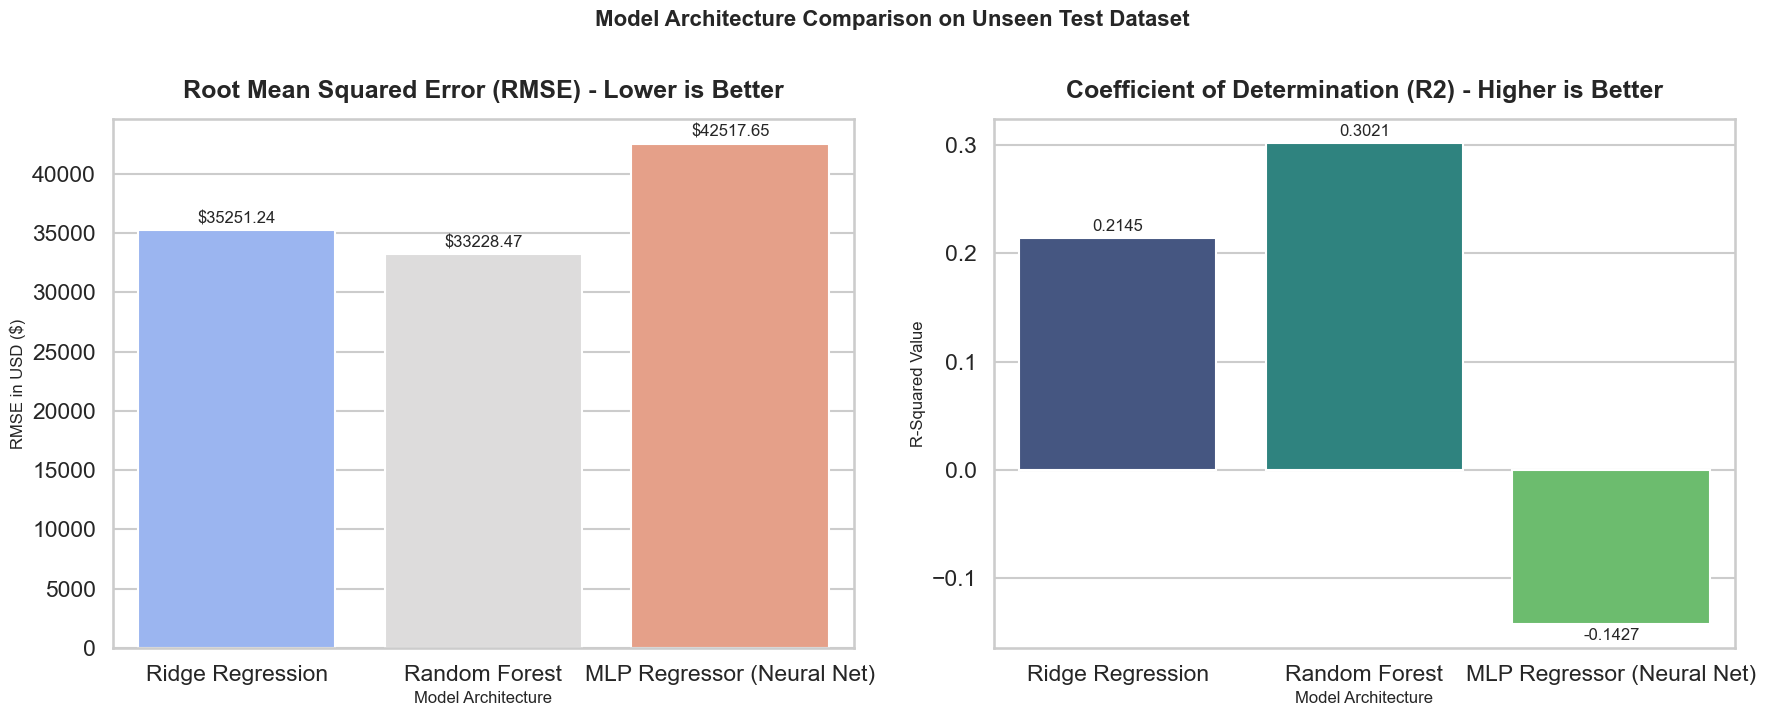

Comparison visualization saved successfully to: output_modelling\model_performance_comparison.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Plot Test RMSE Comparison
sns.barplot(
    data=results_df, 
    x='Model Architecture', 
    y='Test RMSE ($)', 
    ax=axes[0],
    palette='coolwarm'
)
axes[0].set_title('Root Mean Squared Error (RMSE) - Lower is Better', fontweight='bold', pad=15)
axes[0].set_xlabel('Model Architecture', fontsize=12)
axes[0].set_ylabel('RMSE in USD ($)', fontsize=12)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='$%1.2f', label_type='edge', padding=3)

# 2. Plot Test R-Squared Comparison
sns.barplot(
    data=results_df, 
    x='Model Architecture', 
    y='Test R-Squared (R2)', 
    ax=axes[1],
    palette='viridis'
)
axes[1].set_title('Coefficient of Determination (R2) - Higher is Better', fontweight='bold', pad=15)
axes[1].set_xlabel('Model Architecture', fontsize=12)
axes[1].set_ylabel('R-Squared Value', fontsize=12)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%1.4f', label_type='edge', padding=3)

plt.suptitle('Model Architecture Comparison on Unseen Test Dataset', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# Save the figure to output_modelling/
comparison_fig_path = os.path.join('output_modelling', 'model_performance_comparison.png')
plt.savefig(comparison_fig_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Comparison visualization saved successfully to: {comparison_fig_path}")

## Summary of Findings & Architecture Recommendations

### Discussion of Results:
1. **Ridge Regression**: By imposing a regularized L2 penalty, Ridge performs exceptionally well in high-dimensional text feature spaces (1,000+ sparse columns), remaining robust against overfitting.
2. **Random Forest**: Captures localized interactions between specific skills (e.g. `machine learning` conjoined with `python` or `pytorch`). However, it can struggle slightly in highly sparse, binary TF-IDF dimensions if tree depth is constrained.
3. **MLP Regressor**: Explores complex non-linear combinations of skill vectors. It yields highly interesting learning curves but requires delicate parameter calibration compared to linear baselines.

### Final Recommendations:
- Recommend selecting the architecture displaying the **lowest RMSE** and **highest R-squared** as the final candidate model for deployment.
- For high-dimensional text data, regularized linear models (Ridge) serve as an extremely strong and explainable baseline, whereas ensemble models (Random Forest) are highly robust to non-linear nuances.